In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [8]:
df_features = pd.read_csv("C:\\Users\\yusif\\Downloads\\archive (1)\\Features data set.csv")

In [10]:
df_features

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [6]:
df_sales = pd.read_csv("C:\\Users\\yusif\\Downloads\\archive (1)\\sales data-set.csv")

In [7]:
df_sales

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False
...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False
421566,45,98,05/10/2012,628.10,False
421567,45,98,12/10/2012,1061.02,False
421568,45,98,19/10/2012,760.01,False


In [11]:
df_stores = pd.read_csv("C:\\Users\\yusif\\Downloads\\archive (1)\\stores data-set.csv")

In [12]:
df_stores

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [15]:
df = pd.merge(df_sales, df_features, on = ['Store','Date'], how = 'left')
df = pd.merge(df, df_stores, on = 'Store', how = 'left')
print(df)

        Store  Dept        Date  Weekly_Sales  IsHoliday_x  Temperature  \
0           1     1  05/02/2010      24924.50        False        42.31   
1           1     1  12/02/2010      46039.49         True        38.51   
2           1     1  19/02/2010      41595.55        False        39.93   
3           1     1  26/02/2010      19403.54        False        46.63   
4           1     1  05/03/2010      21827.90        False        46.50   
...       ...   ...         ...           ...          ...          ...   
421565     45    98  28/09/2012        508.37        False        64.88   
421566     45    98  05/10/2012        628.10        False        64.89   
421567     45    98  12/10/2012       1061.02        False        54.47   
421568     45    98  19/10/2012        760.01        False        56.47   
421569     45    98  26/10/2012       1076.80        False        58.85   

        Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0            2.572    

In [16]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,05/02/2010,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,12/02/2010,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,19/02/2010,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,26/02/2010,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,05/03/2010,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,False,B,118221
421566,45,98,05/10/2012,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,False,B,118221
421567,45,98,12/10/2012,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,False,B,118221
421568,45,98,19/10/2012,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,False,B,118221


In [17]:
print(df.columns.tolist())

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size']


In [19]:
(df['IsHoliday_x'] == df['IsHoliday_y']).all()

np.True_

In [20]:
df = df.drop(columns = ['IsHoliday_y']).rename(columns={'IsHoliday_x': 'IsHoliday'})

In [21]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,05/02/2010,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,12/02/2010,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,19/02/2010,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,26/02/2010,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,05/03/2010,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,05/10/2012,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,12/10/2012,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,19/10/2012,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221


In [22]:
print(df.shape)
print(df.head())

(421570, 16)
   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  05/02/2010      24924.50      False        42.31       2.572   
1      1     1  12/02/2010      46039.49       True        38.51       2.548   
2      1     1  19/02/2010      41595.55      False        39.93       2.514   
3      1     1  26/02/2010      19403.54      False        46.63       2.561   
4      1     1  05/03/2010      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [24]:
percent_missing = (df.isnull().sum() / len(df)) *100

In [25]:
percent_missing

Store            0.000000
Dept             0.000000
Date             0.000000
Weekly_Sales     0.000000
IsHoliday        0.000000
Temperature      0.000000
Fuel_Price       0.000000
MarkDown1       64.257181
MarkDown2       73.611025
MarkDown3       67.480845
MarkDown4       67.984676
MarkDown5       64.079038
CPI              0.000000
Unemployment     0.000000
Type             0.000000
Size             0.000000
dtype: float64

In [30]:
df = df.drop(columns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'])
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,05/02/2010,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,12/02/2010,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,19/02/2010,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,26/02/2010,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,05/03/2010,21827.90,False,46.50,2.625,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False,64.88,3.997,192.013558,8.684,B,118221
421566,45,98,05/10/2012,628.10,False,64.89,3.985,192.170412,8.667,B,118221
421567,45,98,12/10/2012,1061.02,False,54.47,4.000,192.327265,8.667,B,118221
421568,45,98,19/10/2012,760.01,False,56.47,3.969,192.330854,8.667,B,118221


In [32]:
df['Date'] = pd.to_datetime(df['Date'],format = '%d/%m/%Y')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   CPI           421570 non-null  float64       
 8   Unemployment  421570 non-null  float64       
 9   Type          421570 non-null  object        
 10  Size          421570 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(5), int64(3), object(1)
memory usage: 32.6+ MB


### First ,we start to project with 1 store 

In [41]:
df[df['Date'] == '2010-02-05']

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
143,1,2,2010-02-05,50605.27,False,42.31,2.572,211.096358,8.106,A,151315
286,1,3,2010-02-05,13740.12,False,42.31,2.572,211.096358,8.106,A,151315
429,1,4,2010-02-05,39954.04,False,42.31,2.572,211.096358,8.106,A,151315
572,1,5,2010-02-05,32229.38,False,42.31,2.572,211.096358,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...
420727,45,92,2010-02-05,68203.08,False,27.31,2.784,181.871190,8.992,B,118221
420870,45,93,2010-02-05,4002.34,False,27.31,2.784,181.871190,8.992,B,118221
421147,45,95,2010-02-05,63833.63,False,27.31,2.784,181.871190,8.992,B,118221
421292,45,97,2010-02-05,8393.22,False,27.31,2.784,181.871190,8.992,B,118221


In [35]:
store1 = df[df['Store'] == 1]

In [36]:
weekly_sales = store1.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_sales = weekly_sales.sort_values('Date')

In [37]:
print(weekly_sales.shape)
weekly_sales.head()

(143, 2)


,Date,Weekly_Sales
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68


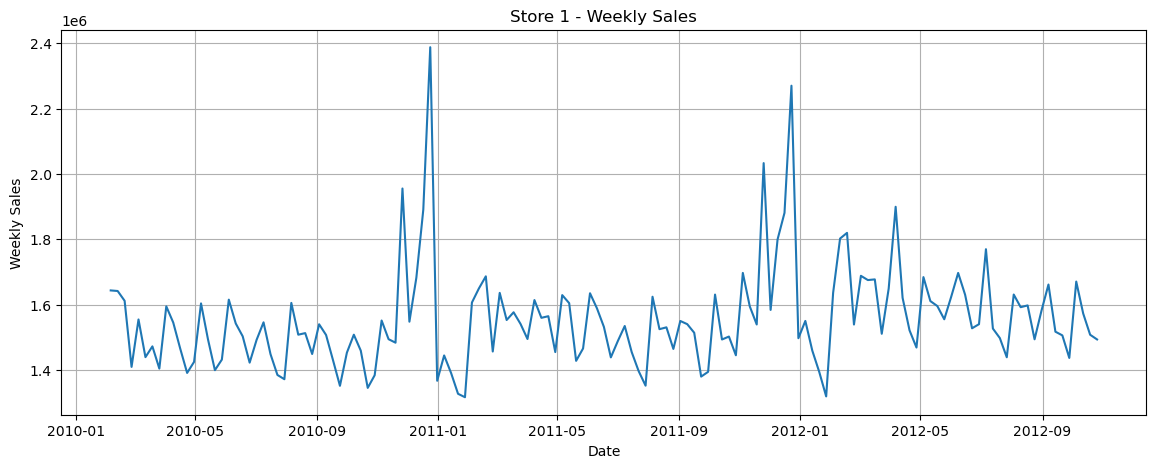

In [42]:
# Draw the visual
plt.figure(figsize =(14, 5))
plt.plot(weekly_sales['Date'], weekly_sales['Weekly_Sales'])
plt.title('Store 1 - Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

It seems stable in terms of trend, but this is not stationarity, and in terms of seasonality, there are annual peaks (which also coincide with the new year).

In [44]:
weekly_sales_index  = weekly_sales.set_index('Date')

In [45]:
weekly_sales_index

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68
...,...
2012-09-28,1437059.26
2012-10-05,1670785.97
2012-10-12,1573072.81


In [46]:
decomp = seasonal_decompose(weekly_sales_index['Weekly_Sales'], model = 'additive')

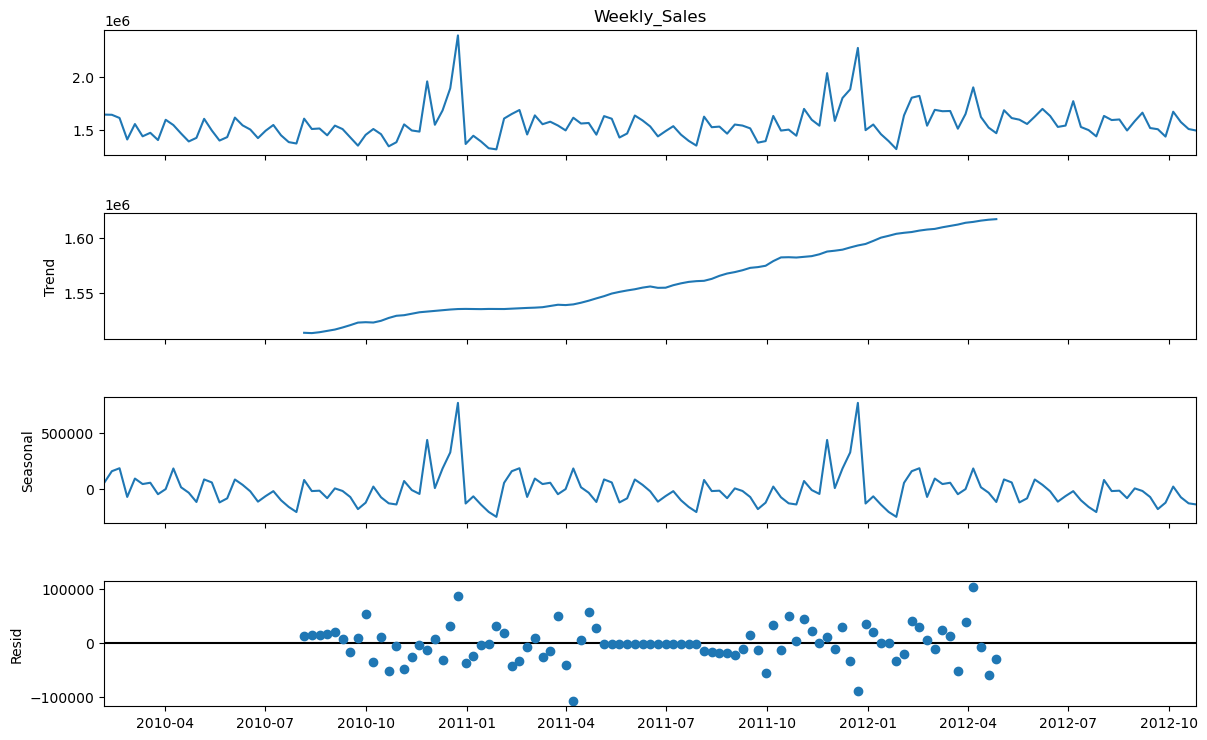

In [47]:
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.show()

- There is a noticeable uptrend, but we need to check this with ADF
- The fluctuations in the residual plot show seasonal differences that we don't see, but for the most part the data looks good except for the peaks

In [50]:
res = adfuller(weekly_sales['Weekly_Sales'])

print('ADF:',res[0])
print('p-value:',res[1])

ADF: -5.102186145192286
p-value: 1.3877788330759535e-05


Statistically, the data is considered stationary (according to ADF), which is what we just thought about in the graph of Store 1 - Weekly Sales.

__It seems that there is no trend, but seasonality is definitely there. For this, we will use the SARIMA model, but first, let's use ACF and PACF to choose its parameters__

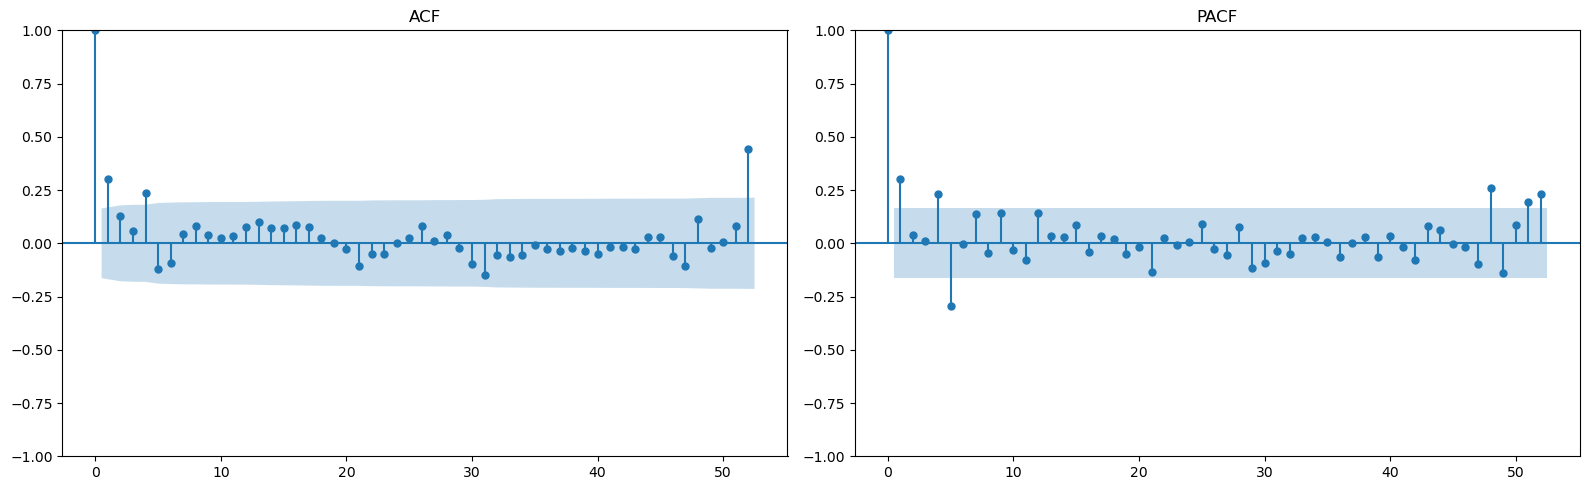

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(weekly_sales['Weekly_Sales'], lags = 52, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(weekly_sales['Weekly_Sales'], lags=52, ax=axes[1])
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

__These charts show us that:__

- The data has a weekly short-term relationship (lag 1)
- The data has a yearly recurring pattern (lag 52 — holiday peaks)

__We chose SARIMA but let's add parameters
daily -(p, d, q)
seasonal - (P, D, Q, s)__
- d
Is there a trend in our data? = 0
- p
How many weeks should we look back? In PACF = 1 (week ago)
- q
How many steps should we remember the error? In ACF = 1 (week)
- s
How many steps is 1 period? = 52
- D
Should we get an annual trend? = 1
- P
What happened this time last year? Strong sign in lag52 = 1
- Q
Should we remember last year's error? = 1

__SARIMA (1, 0, 1) (1, 1, 1, 52)__

In [54]:
train_size = int(len(weekly_sales) * 0.85)
train = weekly_sales['Weekly_Sales'][:train_size]
test = weekly_sales['Weekly_Sales'][train_size:]
print(train.shape, test.shape)

(121,) (22,)


In [55]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, order=(1, 0, 1), seasonal_order = (1, 1, 1, 52))
result = model.fit()

print(result.summary())

D:\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  121
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 52)   Log Likelihood                -866.730
Date:                            Sat, 04 Jul 2026   AIC                           1743.461
Time:                                    18:23:17   BIC                           1754.631
Sample:                                         0   HQIC                          1747.892
                                            - 121                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3975      1.730      0.230      0.818      -2.994       3.789
ma.L1         -0.4324      1.625   

In [56]:
model2 = SARIMAX(train, order=(0, 0, 0), seasonal_order=(1, 1, 1, 52))
result2 = model2.fit()
print(result2.summary())

D:\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                 SARIMAX Results                                  
Dep. Variable:               Weekly_Sales   No. Observations:                  121
Model:             SARIMAX(1, 1, [1], 52)   Log Likelihood                -866.699
Date:                    Sat, 04 Jul 2026   AIC                           1739.398
Time:                            18:26:35   BIC                           1746.100
Sample:                                 0   HQIC                          1742.057
                                    - 121                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L52       0.9984      0.048     20.876      0.000       0.905       1.092
ma.S.L52      -0.9892      0.162     -6.103      0.000      -1.307      -0.671
sigma2      4.445e+0

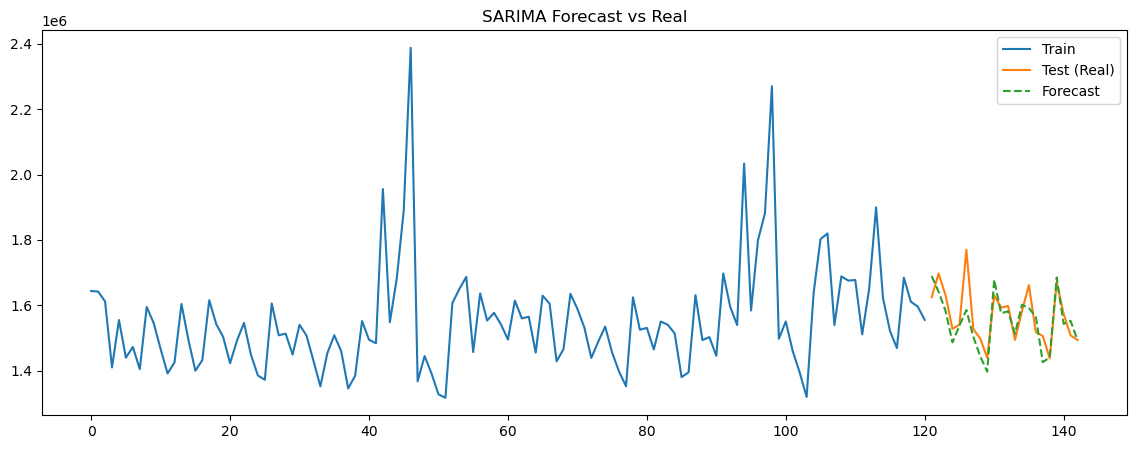

In [58]:
f_c = result2.get_forecast(steps=len(test))
pred = f_c.predicted_mean

plt.figure(figsize=(14,5))
plt.plot(train.index, train, label ='Train')
plt.plot(test.index, test, label='Test (Real)')
plt.plot(test.index, pred, label = 'Forecast', linestyle = '--')
plt.legend()
plt.title('SARIMA Forecast vs Real')
plt.show()

In [63]:
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = (mae/test.mean()) * 100

print('mae:',mae)
print('rmse:', rmse)
print('mape', mape)

mae: 42100.761124761106
rmse: 56711.65915313777
mape 2.6831216137776637


### Now we check Prophet

In [64]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.1 MB 4.1 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.1 MB 5.2 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.1 MB 5.8 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/12.1 MB 5.2 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/12.1 MB 5.3 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.1 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 5.4 MB/s eta 0:00:01
   ----------------------------------- ---- 10.7/12.1 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 5.0 MB/s  0:00:02
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------------

In [65]:
prop_df = weekly_sales.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

prop_df.head()

,ds,y
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68


In [66]:
train_size_p = int(len(prop_df) *0.85)
train_p = prop_df[:train_size_p]
test_p = prop_df[train_size_p:]

print(train_p.shape, test_p.shape)

(121, 2) (22, 2)


In [67]:
from prophet import Prophet

In [69]:
model_p = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = False,
    daily_seasonality = False
)
model_p.fit(train_p)

18:56:07 - cmdstanpy - INFO - Chain [1] start processing
18:56:08 - cmdstanpy - INFO - Chain [1] done processing


In [70]:
future = model_p.make_future_dataframe(periods=len(test_p), freq='W')
f_c_prop = model_p.predict(future)

In [71]:
pred_prop = f_c_prop['yhat'][-len(test_p):].values
print(pred_prop[:5])

[1594473.71991495 1590476.89394128 1606464.30093825 1624633.29028461
 1614653.35534658]


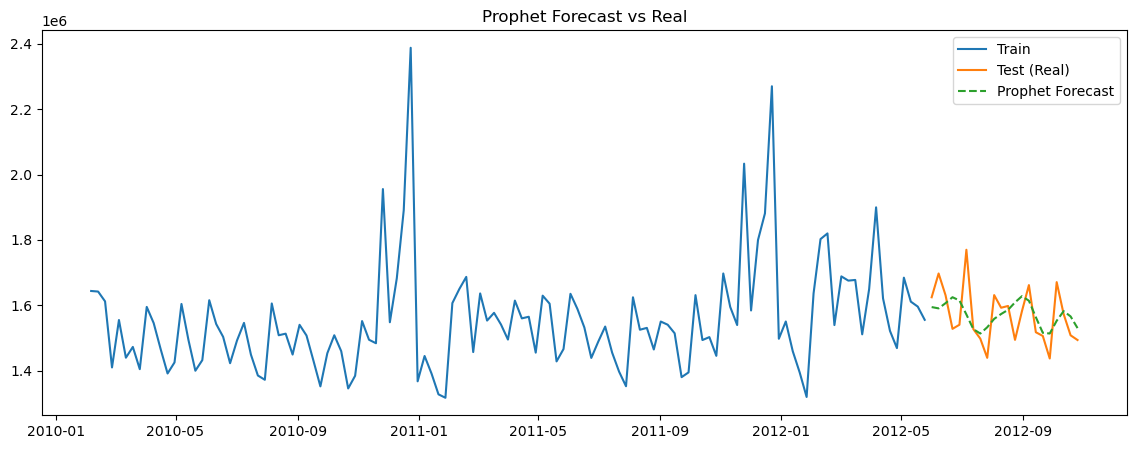

In [72]:
plt.figure(figsize=(14,5))
plt.plot(train_p['ds'], train_p['y'], label='Train')
plt.plot(test_p['ds'], test_p['y'], label='Test (Real)')
plt.plot(test_p['ds'], pred_prop, label='Prophet Forecast', linestyle='--')
plt.legend()
plt.title('Prophet Forecast vs Real')
plt.show()

In [75]:
mae_prop = mean_absolute_error(test_p['y'], pred_prop)
rmse_prop = np.sqrt(mean_squared_error(test_p['y'], pred_prop))
mape_prop = (mae_prop / test_p['y'].mean()) * 100

print('mae:', mae_prop)
print('rmse:', rmse_prop)
print('mAPE:', mape_prop)

mae: 59309.45031602909
rmse: 75707.41259705769
mAPE: 3.779847769797609


- __The results show that SARIMA is stronger than Prophet, which may be due to the smaller data set. Prophet works especially well on large data sets__
- __We manually tuned SARIMA, which gives us an advantage__
- __SARIMA works better on simple seasonal patterns like this__